<a href="https://colab.research.google.com/github/sharmamalika2000-bot/ML_projects/blob/main/SVM_breast_cancer_2dec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler



In [ ]:
from sklearn.datasets import load_breast_cancer

In [ ]:
data=load_breast_cancer()
df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target

In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
df['target'].value_counts()

,count
target,
1,357
0,212


In [ ]:
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


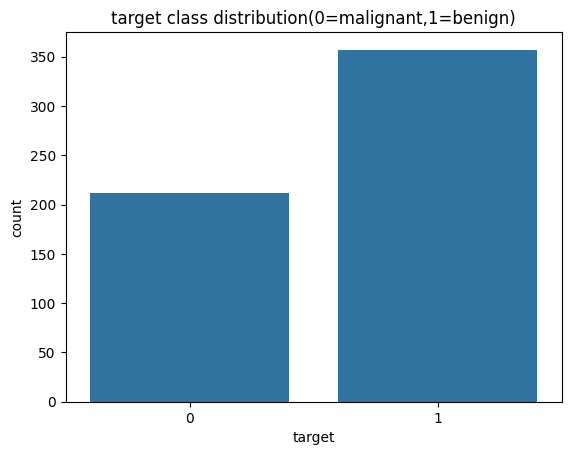

In [ ]:
sns.countplot(x='target',data=df)
plt.title('target class distribution(0=malignant,1=benign)')
plt.show()

heatmap

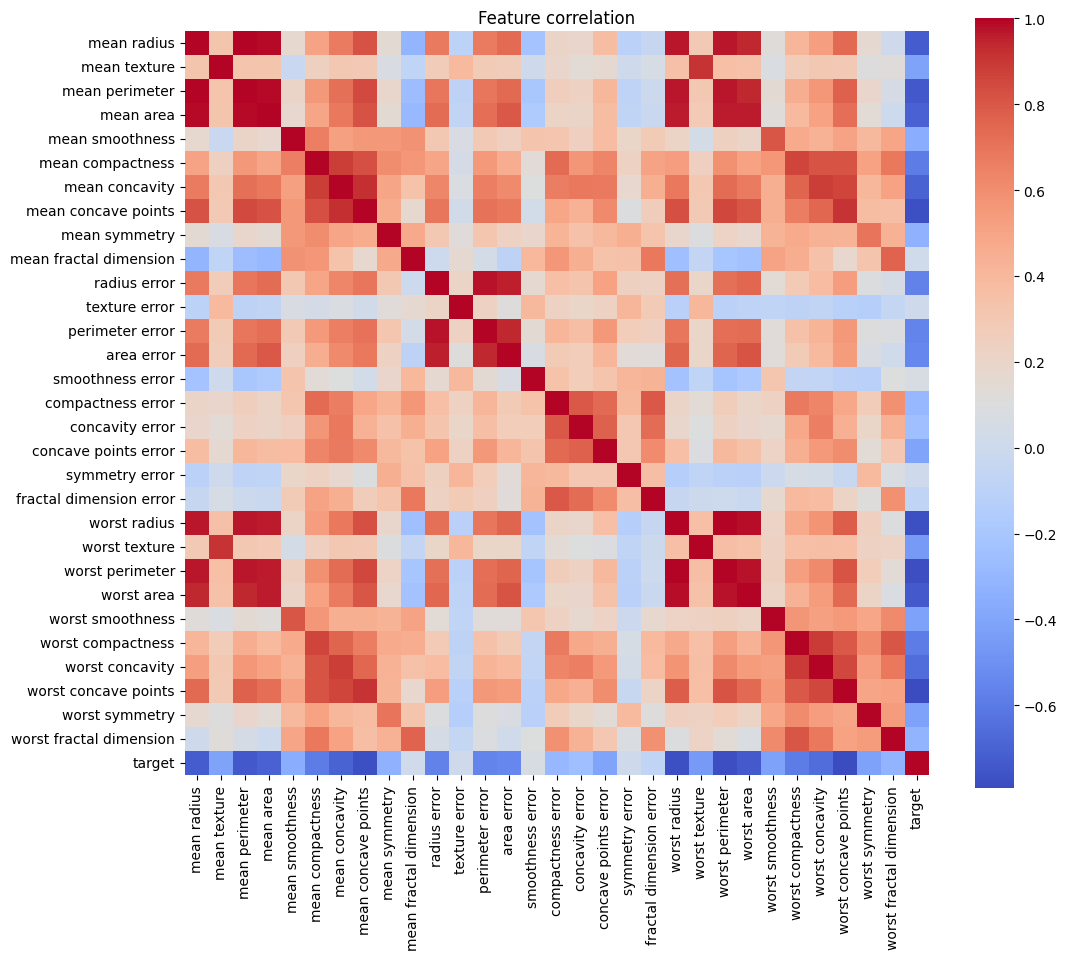

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),cmap='coolwarm',square=True)
plt.title('Feature correlation')
plt.show()

In [ ]:
#drop near zero variance columns
from sklearn.feature_selection import VarianceThreshold
selector=VarianceThreshold(threshold=0.01)
x=selector.fit_transform(df.drop('target',axis=1))

update features names after the variance filter

In [ ]:
features=df.drop('target',axis=1).columns[selector.get_support()]

In [ ]:
features

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst compactness', 'worst concavity'],
      dtype='object')

In [ ]:
#define x and y
x=pd.DataFrame(x,columns=features)
y=df['target']

In [ ]:
x

,mean radius,mean texture,mean perimeter,mean area,radius error,texture error,perimeter error,area error,worst radius,worst texture,worst perimeter,worst area,worst compactness,worst concavity
0,17.99,10.38,122.80,1001.0,1.0950,0.9053,8.589,153.40,25.380,17.33,184.60,2019.0,0.66560,0.7119
1,20.57,17.77,132.90,1326.0,0.5435,0.7339,3.398,74.08,24.990,23.41,158.80,1956.0,0.18660,0.2416
2,19.69,21.25,130.00,1203.0,0.7456,0.7869,4.585,94.03,23.570,25.53,152.50,1709.0,0.42450,0.4504
3,11.42,20.38,77.58,386.1,0.4956,1.1560,3.445,27.23,14.910,26.50,98.87,567.7,0.86630,0.6869
4,20.29,14.34,135.10,1297.0,0.7572,0.7813,5.438,94.44,22.540,16.67,152.20,1575.0,0.20500,0.4000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,1.1760,1.2560,7.673,158.70,25.450,26.40,166.10,2027.0,0.21130,0.4107
565,20.13,28.25,131.20,1261.0,0.7655,2.4630,5.203,99.04,23.690,38.25,155.00,1731.0,0.19220,0.3215
566,16.60,28.08,108.30,858.1,0.4564,1.0750,3.425,48.55,18.980,34.12,126.70,1124.0,0.30940,0.3403
567,20.60,29.33,140.10,1265.0,0.7260,1.5950,5.772,86.22,25.740,39.42,184.60,1821.0,0.86810,0.9387


In [ ]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
564,0
565,0
566,0
567,0


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 455 entries, 546 to 474
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mean radius        455 non-null    float64
 1   mean texture       455 non-null    float64
 2   mean perimeter     455 non-null    float64
 3   mean area          455 non-null    float64
 4   radius error       455 non-null    float64
 5   texture error      455 non-null    float64
 6   perimeter error    455 non-null    float64
 7   area error         455 non-null    float64
 8   worst radius       455 non-null    float64
 9   worst texture      455 non-null    float64
 10  worst perimeter    455 non-null    float64
 11  worst area         455 non-null    float64
 12  worst compactness  455 non-null    float64
 13  worst concavity    455 non-null    float64
dtypes: float64(14)
memory usage: 53.3 KB


In [ ]:
x_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114 entries, 256 to 488
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mean radius        114 non-null    float64
 1   mean texture       114 non-null    float64
 2   mean perimeter     114 non-null    float64
 3   mean area          114 non-null    float64
 4   radius error       114 non-null    float64
 5   texture error      114 non-null    float64
 6   perimeter error    114 non-null    float64
 7   area error         114 non-null    float64
 8   worst radius       114 non-null    float64
 9   worst texture      114 non-null    float64
 10  worst perimeter    114 non-null    float64
 11  worst area         114 non-null    float64
 12  worst compactness  114 non-null    float64
 13  worst concavity    114 non-null    float64
dtypes: float64(14)
memory usage: 13.4 KB


In [ ]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 455 entries, 546 to 474
Series name: target
Non-Null Count  Dtype
--------------  -----
455 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


In [ ]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 114 entries, 256 to 488
Series name: target
Non-Null Count  Dtype
--------------  -----
114 non-null    int64
dtypes: int64(1)
memory usage: 1.8 KB


In [ ]:
y_train

,target
546,1
432,0
174,1
221,1
289,1
...,...
184,0
300,0
509,0
230,0


In [ ]:
pipe=Pipeline([
    ('scaler',StandardScaler()),
    ('svc',SVC())
])

In [ ]:
#define pipeline

pips=Pipeline([('scaler',StandardScaler(),('svc()'))])

HyperParameter Tuning and GridSearch

In [ ]:
param_grid={
    'svc__kernel':['linear','rbf'],
    'svc__C':[0.1,1,10,100],
    'svc__gamma':['scale',0.01,0.001]     #gammaa used for curved boundaries for rbf,low gamma (small curves convert into linear)
}

apply grid

In [ ]:
grid=GridSearchCV(pipe,param_grid,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
print("best parameters:",grid.best_params_)

best parameters: {'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


evaluate the model

In [ ]:
_best_model=grid.best_estimator_

prediction

In [ ]:
y_pred=_best_model.predict(x_test)

In [ ]:
y_pred

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [ ]:
accuracy_score(y_test,y_pred)

0.9649122807017544

In [ ]:
confusion_matrix(y_test,y_pred)

array([[39,  3],
       [ 1, 71]])

In [ ]:
classification_report(y_test,y_pred)

'              precision    recall  f1-score   support\n\n           0       0.97      0.93      0.95        42\n           1       0.96      0.99      0.97        72\n\n    accuracy                           0.96       114\n   macro avg       0.97      0.96      0.96       114\nweighted avg       0.97      0.96      0.96       114\n'

save and use the model for inference

In [ ]:
import joblib

In [ ]:
joblib.dump(_best_model,'best_svm_model.pkl')

['best_svm_model.pkl']